In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
# Shape of the dataset
df.shape

(8807, 12)

In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df.describe()


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [14]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

In [15]:
df = df.dropna(subset=["date_added"])

In [16]:
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

In [17]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


## Question 1
Which type of content is available more on Netflix?

In [18]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2666


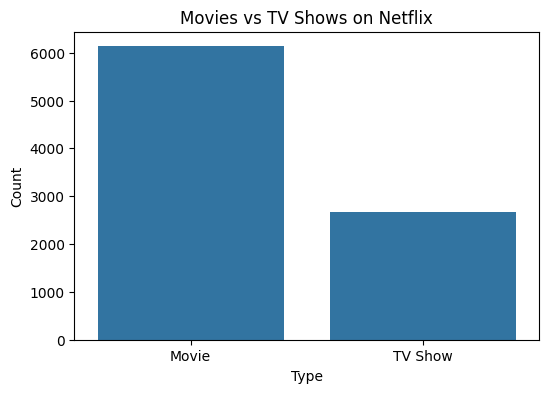

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

## Question 2
Which countries have the highest number of Netflix titles?

In [20]:
top_countries = df["country"].value_counts().head(10)
top_countries

,count
country,
United States,2812
India,972
Unknown,830
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


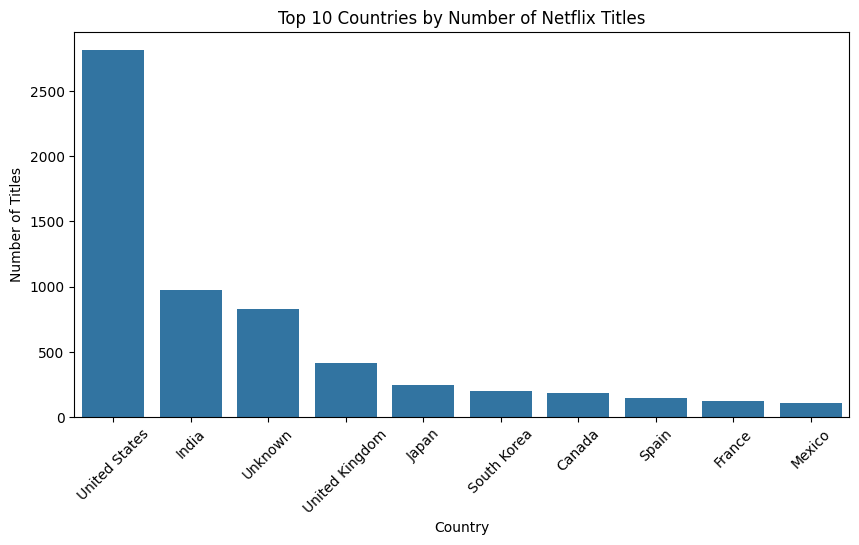

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.index, y=top_countries.values)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

### Insight

The United States has the highest number of Netflix titles.
India and several other countries also contribute significantly to the Netflix library.

## Question 3
How many titles were released each year?

In [22]:
release_year = df["release_year"].value_counts().sort_index()
release_year

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1146
2019,1030


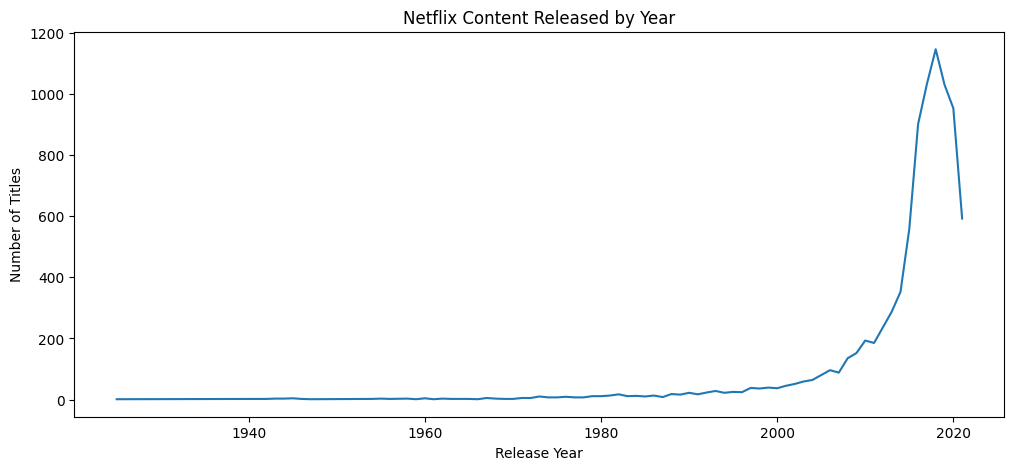

In [23]:
plt.figure(figsize=(12,5))
plt.plot(release_year.index, release_year.values)

plt.title("Netflix Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

### Insight

The number of Netflix titles increased significantly after 2015, showing rapid growth in content production.

## Question 4

Which genres are most common on Netflix?

In [24]:
top_genres = df["listed_in"].str.split(", ").explode().value_counts().head(10)

top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1350
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


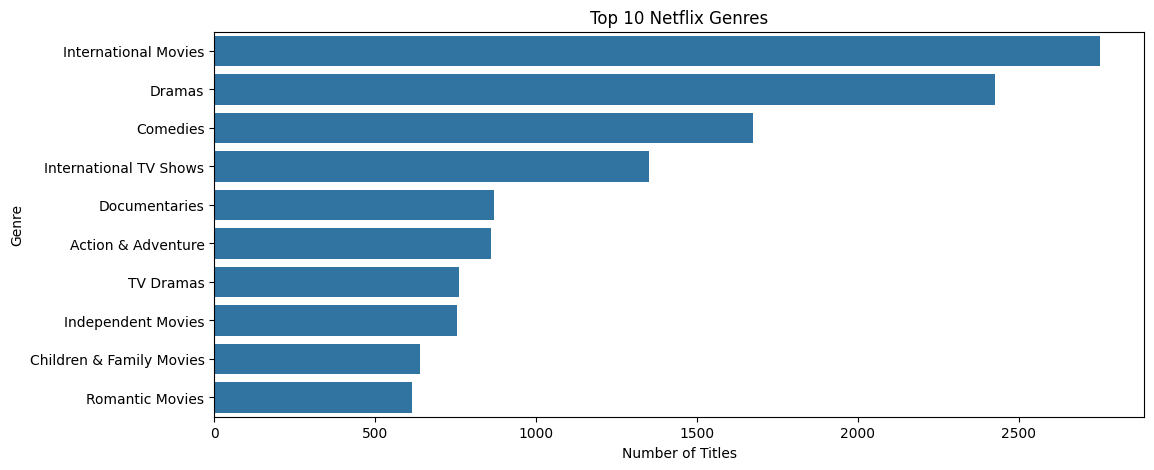

In [25]:
plt.figure(figsize=(12,5))
sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

### Insight

Drama, International Movies, and Comedy are among the most popular genres on Netflix.
This indicates that Netflix offers a wide variety of entertainment, with drama-based content being especially common.

## Question 5

Which content rating appears most frequently?

In [27]:
df["rating"].value_counts()

,count
rating,
TV-MA,3209
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


plt.figure(figsize=(10,5))
sns.countplot(y="rating", data=df, order=df["rating"].value_counts().index)

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")

plt.show()

## Correlation Heatmap

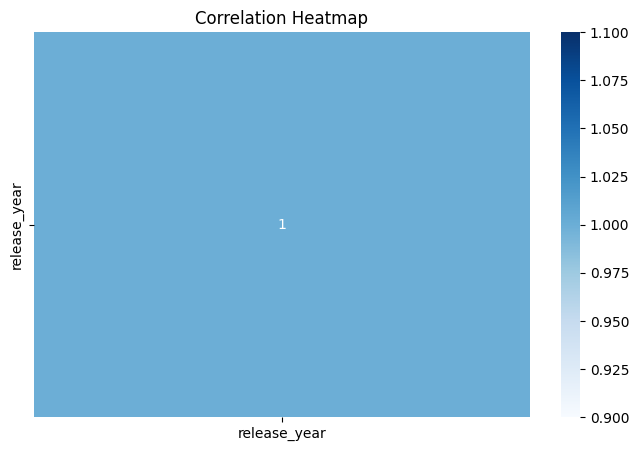

In [28]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")
plt.show()

# Final Insights Report

1. Movies are more common than TV Shows on Netflix.

2. The United States has the largest Netflix content library, followed by other countries like India.

3. Netflix content production increased rapidly after 2015.

4. Drama, International Movies, and Comedy are among the most popular genres.

5. TV-MA and TV-14 are the most common content ratings, indicating a strong focus on mature audiences.

# Conclusion

This project explored the Netflix Movies and TV Shows dataset using Python, Pandas, Matplotlib, and Seaborn. The data was cleaned, analyzed, and visualized to identify meaningful trends. The analysis revealed valuable insights about content type, countries, genres, release years, and audience ratings.

# What surprised me?

The most surprising finding was the rapid increase in Netflix content after 2015. It clearly shows how aggressively Netflix expanded its global content library in recent years.